# QST1 – Visual check of the predictions

For each method, every QST1 query is shown next to the painting it was matched with (top-1 of `result.pkl`).
Run from the `week1` folder (next to `BBDD/`, `qst1_w1/` and `results/`).

In [1]:
import pickle
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

BBDD_DIR = Path("BBDD")
QST_DIR = Path("qst1_w1")
RESULTS = {
    "method1 (HSV 16 bins, χ²)": Path("results/QST1/method1/result.pkl"),
    "method2 (CIELab 32 bins, Hellinger)": Path("results/QST1/method2/result.pkl"),
}
PAIRS_PER_ROW = 5   # pairs (query | match) per row

In [2]:
def load_rgb(path, max_side=300):
    img = cv2.imread(str(path))
    scale = max_side / max(img.shape[:2])
    if scale < 1:
        img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


query_paths = sorted(QST_DIR.glob("*.jpg"))
preds = {name: pickle.load(open(path, "rb")) for name, path in RESULTS.items()}
print(f"{len(query_paths)} queries | " + " | ".join(f"{n}: {len(p)} lists of {len(p[0])}" for n, p in preds.items()))

30 queries | method1 (HSV 16 bins, χ²): 30 lists of 10 | method2 (CIELab 32 bins, Hellinger): 30 lists of 10


In [3]:
def show_pairs(name):
    pred = preds[name]
    n = len(query_paths)
    rows = (n + PAIRS_PER_ROW - 1) // PAIRS_PER_ROW
    fig, axes = plt.subplots(rows, 2 * PAIRS_PER_ROW, figsize=(2 * PAIRS_PER_ROW * 1.6, rows * 2))
    for ax in axes.ravel():
        ax.axis("off")
    for q, qpath in enumerate(query_paths):
        r, c = divmod(q, PAIRS_PER_ROW)
        match = pred[q][0]
        axes[r, 2 * c].imshow(load_rgb(qpath))
        axes[r, 2 * c].set_title(f"query {qpath.stem}", fontsize=8)
        axes[r, 2 * c + 1].imshow(load_rgb(BBDD_DIR / f"bbdd_{match:05d}.jpg"))
        axes[r, 2 * c + 1].set_title(f"→ bbdd_{match:05d}", fontsize=8, color="#2a78d6")
    fig.suptitle(name, fontsize=13)
    plt.tight_layout()
    plt.show()

## Method 1

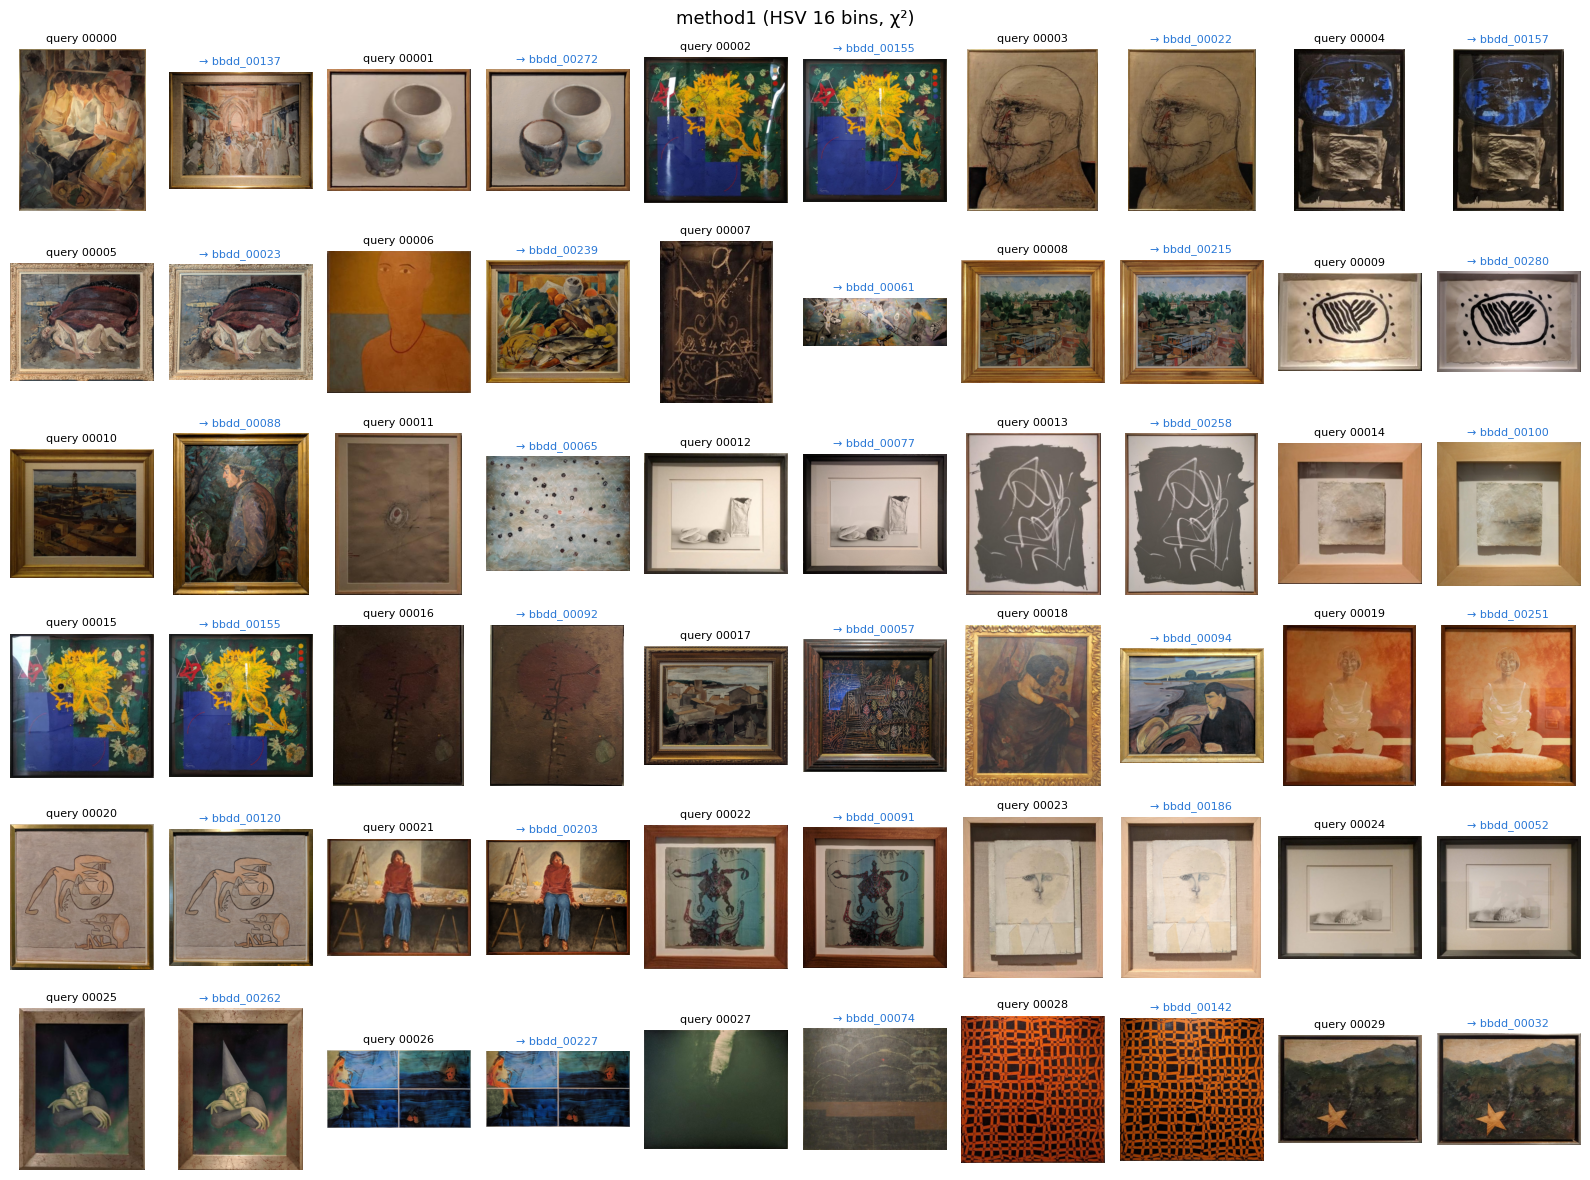

In [4]:
show_pairs("method1 (HSV 16 bins, χ²)")

## Method 2

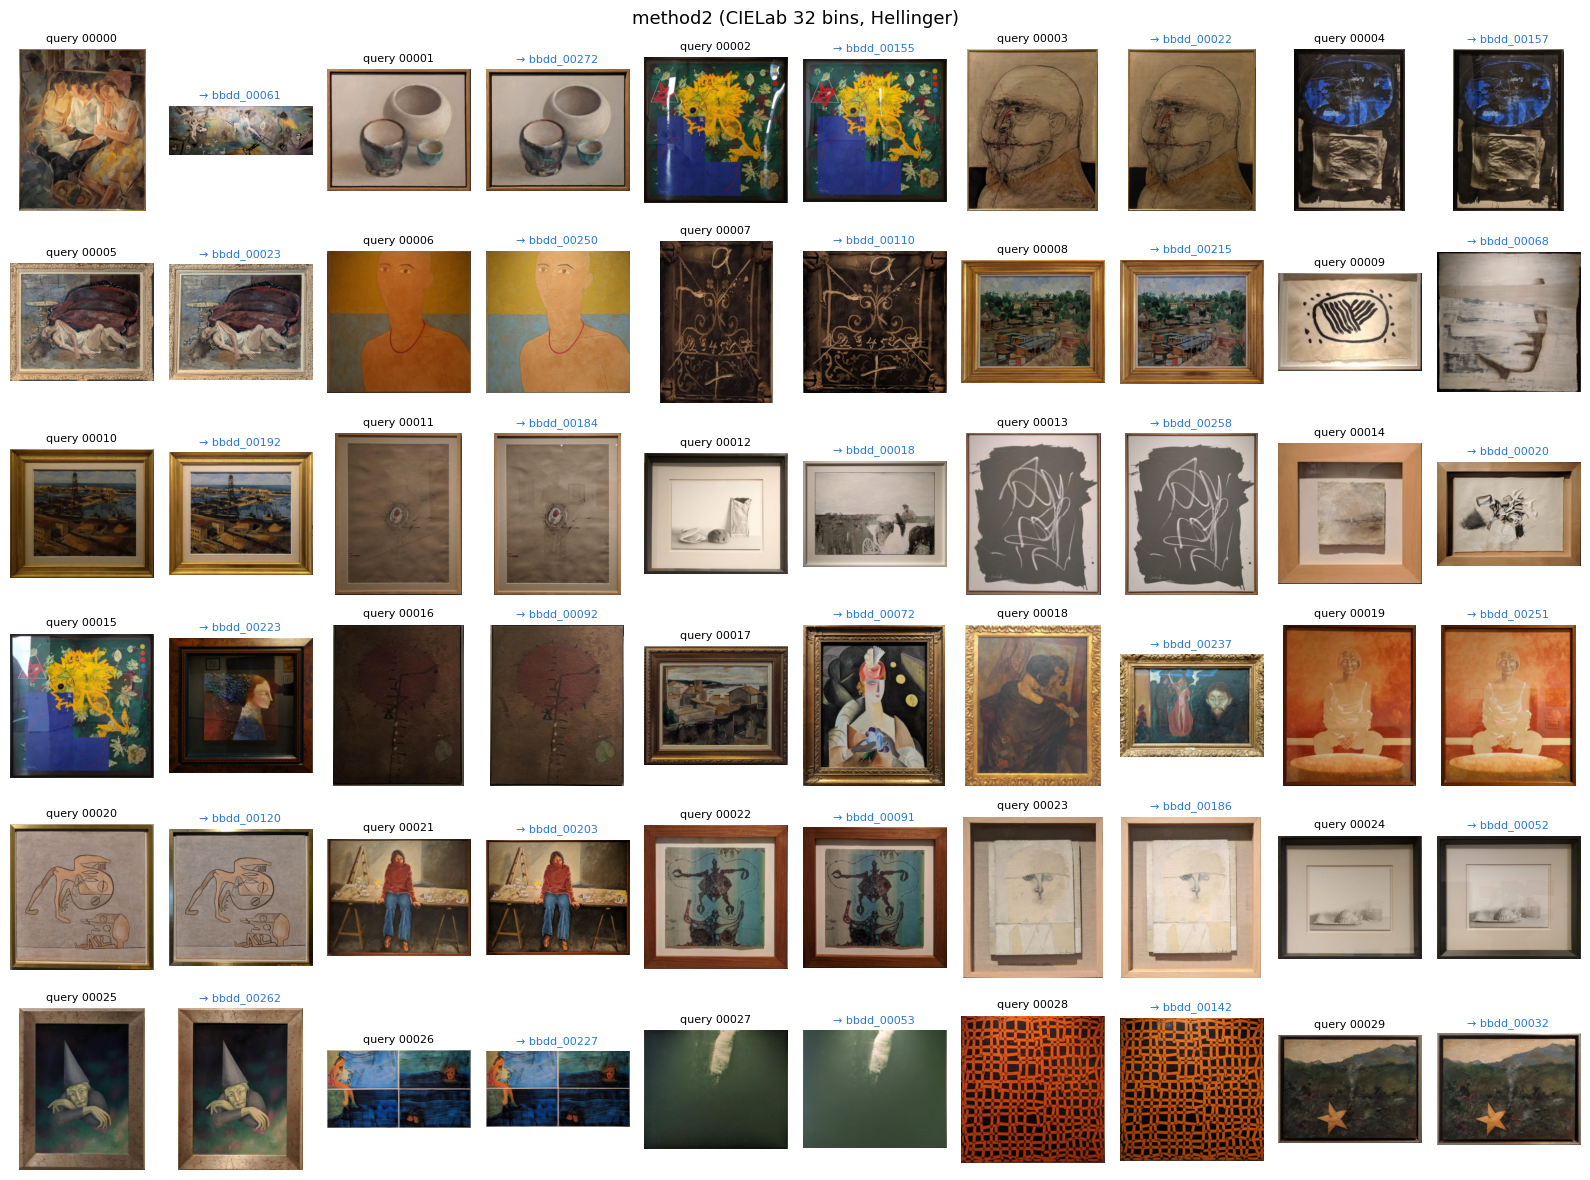

In [5]:
show_pairs("method2 (CIELab 32 bins, Hellinger)")

## Top-10 of one query

The `result.pkl` stores 10 results per query. Change `q` to see all of them for both methods.

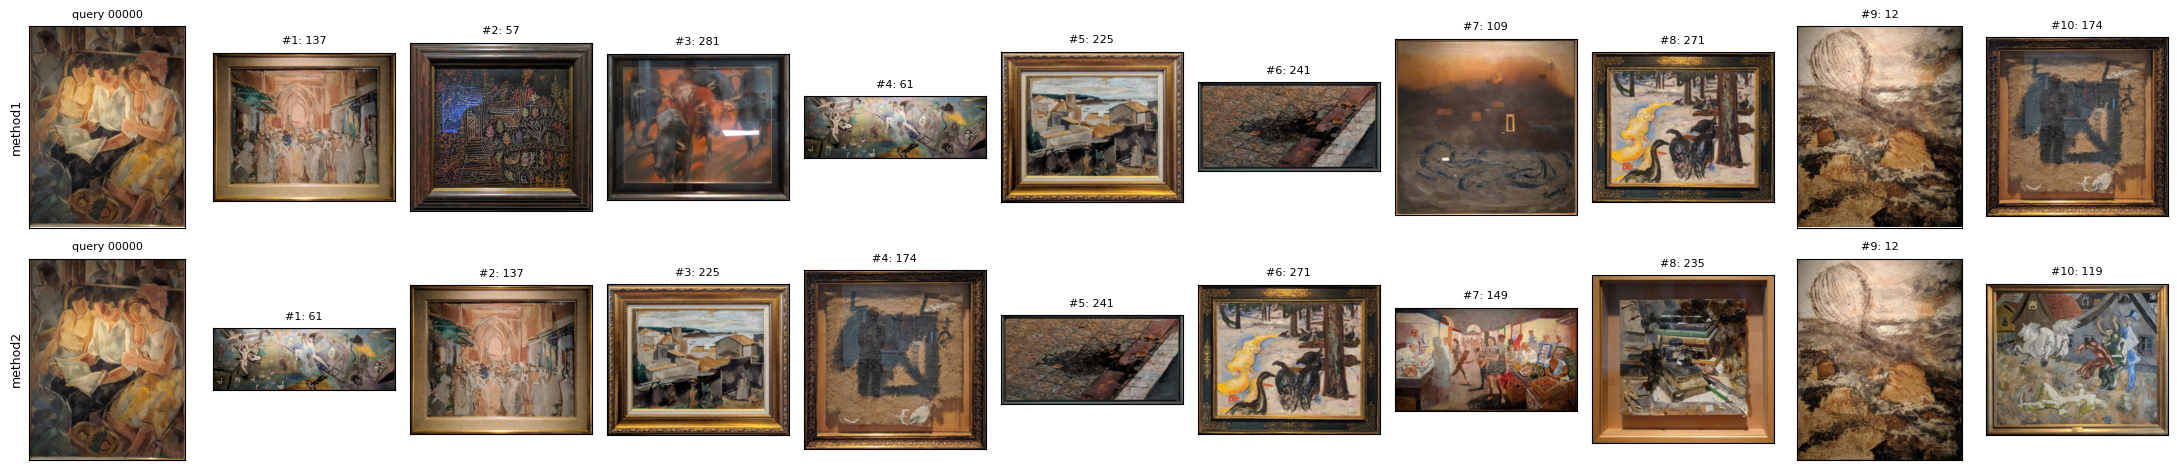

In [6]:
def show_top10(q):
    fig, axes = plt.subplots(len(preds), 11, figsize=(22, 2.4 * len(preds)))
    for r, (name, pred) in enumerate(preds.items()):
        axes[r, 0].imshow(load_rgb(query_paths[q]))
        axes[r, 0].set_title(f"query {query_paths[q].stem}", fontsize=8)
        axes[r, 0].set_ylabel(name.split(" ")[0], fontsize=9)
        for k, bid in enumerate(pred[q], start=1):
            axes[r, k].imshow(load_rgb(BBDD_DIR / f"bbdd_{bid:05d}.jpg"))
            axes[r, k].set_title(f"#{k}: {bid}", fontsize=8)
        for ax in axes[r]:
            ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()


q = 0
show_top10(q)